In [139]:
import numpy as np
import torch
from torchvision import transforms, datasets
import tensorkrowch as tk

import jax
import jax.numpy as jnp

import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import glob
import yaml
import matplotlib.pyplot as plt
import torchtt as tntt 

import sys
import os


sys.path.append('../src/')
sys.path.append('../scripts/')

from run_inference import run_inference
from plots import bar_plot_strings_comparison, plot_training_loss
from MLP_to_H import load_config, min_power_of_2, prepare_initial_state, initial_state_from_input, OperatorClass, physics_computation, generate_bitstring_list, create_filename_core
from plots import bar_plot_strings_comparison
from model import NeuralNetwork



In [ ]:
# Main parameters

config_file = "../config/MLP_to_H_configuration.yaml"

# Load configuration
print(f"Loading config: {config_file}")
CONFIG = load_config(config_file)

# Main parameters
MLP_input_size = CONFIG['MLP_input_size']
MLP_output_size = CONFIG['MLP_output_size']
CHI = CONFIG['bond_dimension_learning']
learning_mode = CONFIG['learning_mode']
MLP_input_folder = CONFIG['MLP_input_folder']
MLP_input_file = CONFIG['MLP_input_file']
H_input_file = CONFIG['H_input_path']
use_mpo = CONFIG['MPO_ON']
max_mpo_chi = CONFIG['MAX_MPO_CHI']


#Load input
input_data = np.load(f"{MLP_input_file}")

#Run inference with MLP model
bitstring_probs, prediction = run_inference(input_data, MLP_input_folder, use_mpo, max_mpo_chi)

data = np.load(H_input_file, allow_pickle=True)
h_param_dict = data['arr_0'].item()


#Prepare initial state depending on the learning mode selected
if learning_mode == 'output_only':
    initial_state_kind = CONFIG['initial_state_kind']
    L = min_power_of_2(MLP_output_size)
    psi0 = prepare_initial_state(L, initial_state_kind)

    print(f"Learning only output of size {MLP_output_size} with {L} qubits")

elif learning_mode == 'output_from_input':
    L = min_power_of_2(MLP_input_size)
    psi0 = initial_state_from_input(L, input_data.flatten())

    print(f"Learning output from input of size {MLP_input_size} with {L} qubits")

dim = 2**L
#Input of training NN
mps_input_probs = torch.ones((1, L, 2))


#Add missing zeros to bistring probs
if len(bitstring_probs) < dim:
    # Create padded array with zeros
    padded_probs = np.zeros(dim)
    padded_probs[:len(bitstring_probs)] = bitstring_probs
    bitstring_probs = padded_probs


# Initialize Hamiltonian operators
OPS_LIST = OperatorClass(L)
OPS_LIST.add_operators('ZZ')
OPS_LIST.add_operators('X')
OPS_LIST.add_operators('Z')
NUM_COEFFICIENTS = len(OPS_LIST)

# Set random seed
torch.manual_seed(CONFIG["seed_init"])
np.random.seed(CONFIG["seed_init"])

# Calculate output dimension
NN_OUTPUT_DIM = NUM_COEFFICIENTS + sum(
    CONFIG.get(f'{axis}_fields', False) for axis in ['x', 'y', 'z']
) * L

t_grid_fine = torch.arange(0.0, CONFIG["t_max"] + CONFIG["dt"]/2, CONFIG["dt"])


Loading config: ../config/MLP_to_H_configuration.yaml
Predicted class: 0
Learning output from input of size 784 with 10 qubits
ZZ terms added to the Hamiltonian
X terms added to the Hamiltonian
Z terms added to the Hamiltonian


In [141]:
psi_final = physics_computation(h_param_dict, psi0, OPS_LIST, L, t_grid_fine)

Total probability divergence: 1.991846


(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'Learned bitstring probabilities'}, xlabel='Bitstrings', ylabel='Probability'>,
 (<BarContainer object of 10 artists>, <BarContainer object of 10 artists>))

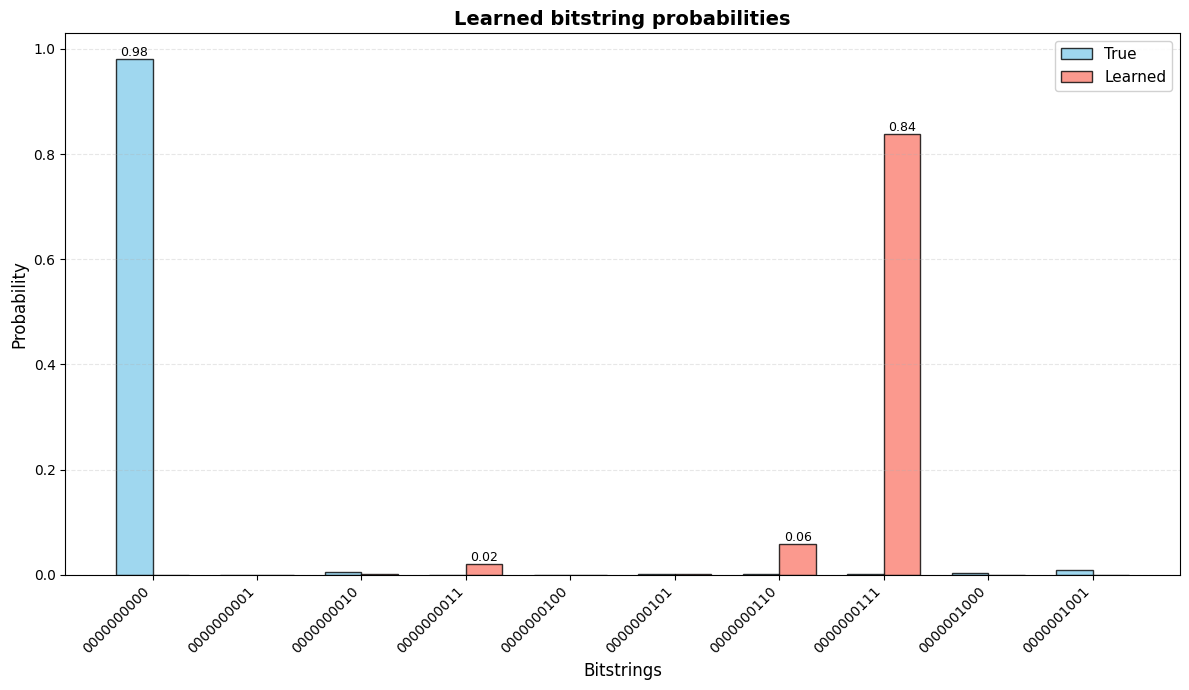

In [142]:
# Compute final probabilities
probs_final = torch.abs(psi_final)**2
probs_np = probs_final.detach().numpy()
probs_np = probs_np / probs_np.sum()

# Normalize counts
normalized_counts = bitstring_probs / bitstring_probs.sum()

# Calculate divergence
total_divergence = np.sum(np.abs(normalized_counts - probs_np))
print(f"Total probability divergence: {total_divergence:.6f}")

bitstrings = generate_bitstring_list(L)

file_core = create_filename_core(CONFIG, L)
limit = int(MLP_output_size)
bar_plot_strings_comparison(bitstrings[0:limit], normalized_counts[0:limit], probs_np[0:limit], file_core)


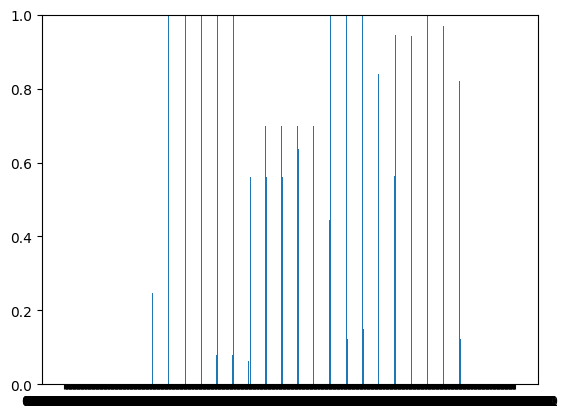

In [132]:
plt.bar(bitstrings[0:784], input_data.flatten())
plt.ylim(0,1)
plt.show()

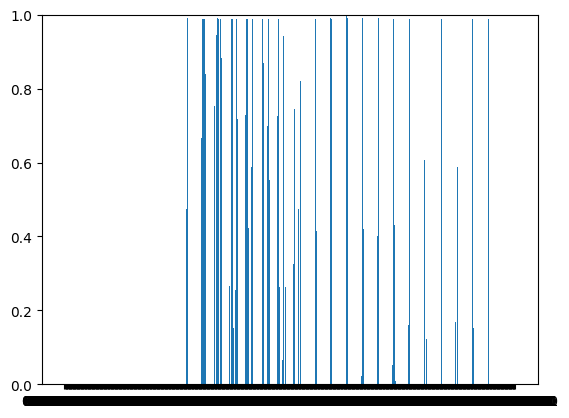

In [138]:
plt.bar(bitstrings[0:784], input_data.flatten())
plt.ylim(0,1)
plt.show()